In [67]:
# import libraries with aliases as short names ("pd" and "plt")
import pandas as pd
import matplotlib.pyplot as plt

In [68]:
# this is a comment, it is not executed
print("TP CompNeuro1") # another comment at the end of the line to say we use the function print

TP CompNeuro1


In [69]:
# read the csv file with correct separators and without header (data start at first line)
pd.read_csv("auditory_test.csv", sep="\t", header=None)

,0,1,2,3,4,5,6,7,8,9,...,14,15,16,17,18,19,20,21,22,23
0,130.0,-480090.973388,55148.280281,-17515.184583,-30423.048785,-530033.711199,-35402.659822,-49200.034046,-51439.947062,0.0,...,1.0,1.0,0.0,0.0,1.0,1.0,256.0,1.0,1.789136e+09,0.0
1,131.0,-479732.987849,55185.562990,-17068.239101,-30476.424751,-529686.901532,-34962.151642,-49272.811326,-51553.315109,0.0,...,1.0,1.0,0.0,0.0,1.0,1.0,256.0,1.0,1.789136e+09,0.0
2,132.0,-477594.998788,55224.365619,-15021.445158,-30586.752961,-527560.267158,-33778.135035,-49385.464118,-51707.720960,0.0,...,1.0,1.0,0.0,0.0,1.0,1.0,256.0,1.0,1.789136e+09,0.0
3,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,...,1.0,1.0,0.0,0.0,1.0,1.0,256.0,1.0,1.789136e+09,0.0
4,1.0,-485566.524931,55046.266919,-17270.656499,-30209.634329,-532718.245115,-35337.035100,-48939.233892,-51480.895457,0.0,...,1.0,1.0,0.0,0.0,1.0,1.0,256.0,1.0,1.789136e+09,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
94551,88.0,-391284.899865,47731.166808,-69663.771351,-21279.575977,-666663.130124,-30229.572085,-35368.685170,-44913.952936,0.0,...,1.0,1.0,0.0,0.0,1.0,1.0,256.0,1.0,1.789137e+09,0.0
94552,89.0,-389271.097096,47880.208240,-67971.386668,-21306.755699,-665008.296371,-30345.711749,-35426.531485,-44891.422378,0.0,...,1.0,1.0,0.0,0.0,1.0,1.0,256.0,1.0,1.789137e+09,0.0
94553,90.0,-390547.739333,47294.592535,-68985.530017,-21225.395349,-666000.535011,-30768.606754,-35327.021519,-44718.598690,0.0,...,1.0,1.0,0.0,0.0,1.0,1.0,256.0,1.0,1.789137e+09,0.0
94554,91.0,-392723.458138,47013.854624,-70768.215748,-21171.482941,-667779.286835,-30739.191859,-35223.309424,-44658.517201,0.0,...,1.0,1.0,0.0,0.0,1.0,1.0,256.0,1.0,1.789137e+09,0.0


In [70]:
# reread the csv and store in a dataframe (from pandas library)
df = pd.read_csv("auditory_test.csv", sep="\t", header=None)

In [71]:
# check the columns of the dataframe
df.columns

Index([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16, 17,
       18, 19, 20, 21, 22, 23],
      dtype='int64')

To find the onset times of the stimuli, we have to find the signal (or time series) indicating the stimulus presentation (steps). 

This time series has low values and high values. To identify onsets, we can define a threshold between the low and high values and test when the time series crosses the threshold from below to above.

To do so, we need to go through the whole time series (with a `for` loop), test the condition for crossing the threshold (`if` keyword) and store teh corresponding time in a variable (`list`).

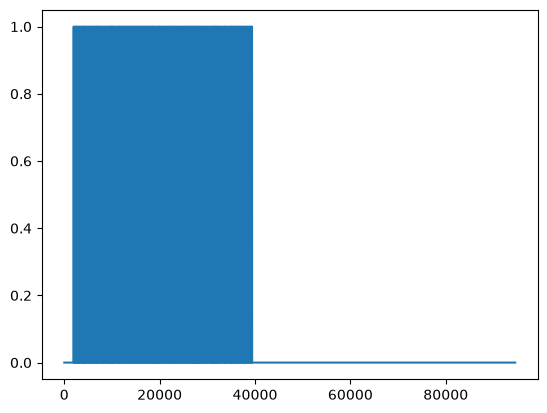

In [72]:
# get the time series for columns 19 and put it in variable "ts"
ts = df[13]

# plot the time series using the plot function from matplotlib.pyplot library (alias plt)
plt.plot(ts)

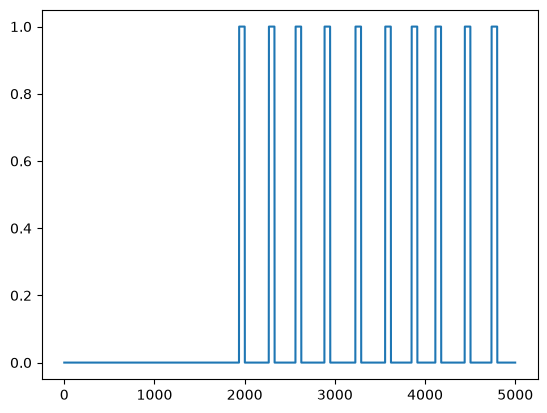

In [73]:
# plot a portion of the time series (up to 5000 time points) to visualize details
plt.plot(ts[0:5000])

In [74]:
# test if time point 1950 is an onset: its value should be above threshold and the value before should be below threshold
print("value at time 1949:", ts[1949])
print("value at time 1950:", ts[1950])

# threshold for test
threshold = 0.5

# display boolean values for the threshold test, which is true or false (useful for conditions later)
print(ts[1950] > threshold)
print(ts[1949] < threshold)

value at time 1949: 1.0
value at time 1950: 1.0
True
False


In [75]:
# automatize the code above for a given time t to test if t is onset
# note that string for the print function have been replaced by formatted string f"..." 
# this is convenient to display the value of a variable at a given place indicated by the brackets {...}
t = 1950
print(f"time {t}")
print(f"value at time t: {ts[t-1]}")
print(f"value at time t-1: {ts[t]}")
threshold = 0.5
print(ts[t] > threshold)
print(ts[t-1] < threshold)

time 1950
value at time t: 1.0
value at time t-1: 1.0
True
False


In [76]:
# get the size of the time series
T = ts.size
print(f"size of the time series ts: {T}")

# alternative option
print(len(ts))

size of the time series ts: 94556
94556


In [77]:
t = 1950
print("time", t)

# test if the value at time t is above or below threshold
if ts[t] > threshold: # condition to be tested
    # this code is executed if the condition is true
    print("ts is greater than threshold at time t")
else:
    # this code is executed if the condition is false
    print("ts is smaller than threshold at time t")

# same for time t-1
if ts[t-1] < threshold:
    print("ts is smaller than threshold at time t-1")
else:
    print("ts is greater than threshold at time t-1")    

time 1950
ts is greater than threshold at time t
ts is greater than threshold at time t-1


In [78]:
print("time", t)
# two conditions combined to test for onset, note the keyword "and"
if ts[t] > threshold and ts[t-1] < threshold:
    print("t is onset")
else:
    print("t is not onset")

time 1950
t is not onset


In [79]:
t = 1938
print("time", t)
if ts[t] > threshold and ts[t-1] < threshold:
    print("t is onset")
else:
    print("t is not onset")

time 1938
t is onset


In [80]:
# create an empty list in variable "l"; an alternative is "l = list()"
l = []

print(type(l))
print("length of l:", len(l))

<class 'list'>
length of l: 0


In [81]:
l.append(2) # add an element to list l
l.append(3) # add an element to list l
l.append(-1) # add an element to list l

# print the length of the list
print(f"length of l {len(l)}")

# display l (all elements)
print("l:", l)

length of l 3
l: [2, 3, -1]


In [82]:
# example loop where "range" determines the indices taken by variable "i"
for i in range(1, 3):
    # execute the indented code at each step (iteration) of the loop
    print(i)

1
2


now we can create a list for onsets and add all times that satisfy the double condition, using a loop to test all times


In [83]:
# now we can create a list for onsets and add all times that satisfy the double condition, using a loop to test all times

# empty list
onsets = []
# loop over all times (indices of the time series ts), starting at t=1 because we use t-1 in the loop
for t in range(1, T):
    # this test is performed at each step of loop
    if ts[t] > threshold and ts[t-1] < threshold:
        # append time to list onsets (if both conditions are true)
        onsets.append(t)

print(onsets)

[1938, 2268, 2564, 2885, 3228, 3558, 3851, 4115, 4440, 4737, 5070, 5427, 5730, 6038, 6363, 6659, 6943, 7230, 7539, 7893, 8224, 8515, 8863, 9210, 9522, 9786, 10065, 10369, 10663, 11023, 11330, 11594, 11898, 12170, 12486, 12835, 13150, 13484, 13799, 14132, 14404, 14705, 15017, 15299, 15618, 15956, 16235, 16579, 16846, 17167, 17440, 17739, 18064, 18372, 18641, 18923, 19232, 19583, 19863, 20149, 20479, 20788, 21150, 21487, 21798, 22110, 22456, 22745, 23057, 23354, 23667, 24028, 24336, 24686, 24993, 25269, 25598, 25934, 26213, 26564, 26864, 27148, 27427, 27747, 28056, 28340, 28663, 29002, 29305, 29649, 30000, 30357, 30704, 30968, 31320, 31598, 31884, 32172, 32513, 32802, 33164, 33518, 33821, 34168, 34520, 34837, 35111, 35437, 35782, 36057, 36398, 36703, 37024, 37356, 37666, 38000, 38336, 38699, 39023, 39312]


other ways to compute the same list of stimulus onsets

In [ ]:
# here we convert the time series to a numpy array using the "to_numpy" method of the pandas series
# here we store the onsets in a numpy array, which is more efficient for large arrays

import numpy as np
stimulus=df[13].to_numpy()

onsets=[]
T=len(stimulus)
t=0
while t<T:
    if stimulus[t]==1:
        onsets.append(t)
        t=t+100
    t=t+1
print(onsets)

[1938, 2268, 2564, 2885, 3228, 3558, 3851, 4115, 4440, 4737, 5070, 5427, 5730, 6038, 6363, 6659, 6943, 7230, 7539, 7893, 8224, 8515, 8863, 9210, 9522, 9786, 10065, 10369, 10663, 11023, 11330, 11594, 11898, 12170, 12486, 12835, 13150, 13484, 13799, 14132, 14404, 14705, 15017, 15299, 15618, 15956, 16235, 16579, 16846, 17167, 17440, 17739, 18064, 18372, 18641, 18923, 19232, 19583, 19863, 20149, 20479, 20788, 21150, 21487, 21798, 22110, 22456, 22745, 23057, 23354, 23667, 24028, 24336, 24686, 24993, 25269, 25598, 25934, 26213, 26564, 26864, 27148, 27427, 27747, 28056, 28340, 28663, 29002, 29305, 29649, 30000, 30357, 30704, 30968, 31320, 31598, 31884, 32172, 32513, 32802, 33164, 33518, 33821, 34168, 34520, 34837, 35111, 35437, 35782, 36057, 36398, 36703, 37024, 37356, 37666, 38000, 38336, 38699, 39023, 39312]


another way to do the same thing is to use the numpy function diff to calculate the derivative : IN ONE LINE MORE ELEGANT WAY

In [ ]:
# here is an alternative way to find the onsets using numpy, which is more efficient for large arrays
# here we use the numpy function "diff" to compute the difference between consecutive values of the time series, and then we find the indices where this difference is positive (i.e. when the signal goes from 0 to 1)
# here we use the numpy function "where" to find the indices of the positive differences, and we add 1 to these indices to get the onsets (because the difference is computed between t and t-1)

onsets=np.where(np.diff(df[13].to_numpy())>0)[0]+1  # Find the indices of the onsets / when derivative is positive (i.e. when the signal  goes from 0 to 1)
print(onsets)

[ 1938  2268  2564  2885  3228  3558  3851  4115  4440  4737  5070  5427
  5730  6038  6363  6659  6943  7230  7539  7893  8224  8515  8863  9210
  9522  9786 10065 10369 10663 11023 11330 11594 11898 12170 12486 12835
 13150 13484 13799 14132 14404 14705 15017 15299 15618 15956 16235 16579
 16846 17167 17440 17739 18064 18372 18641 18923 19232 19583 19863 20149
 20479 20788 21150 21487 21798 22110 22456 22745 23057 23354 23667 24028
 24336 24686 24993 25269 25598 25934 26213 26564 26864 27148 27427 27747
 28056 28340 28663 29002 29305 29649 30000 30357 30704 30968 31320 31598
 31884 32172 32513 32802 33164 33518 33821 34168 34520 34837 35111 35437
 35782 36057 36398 36703 37024 37356 37666 38000 38336 38699 39023 39312]


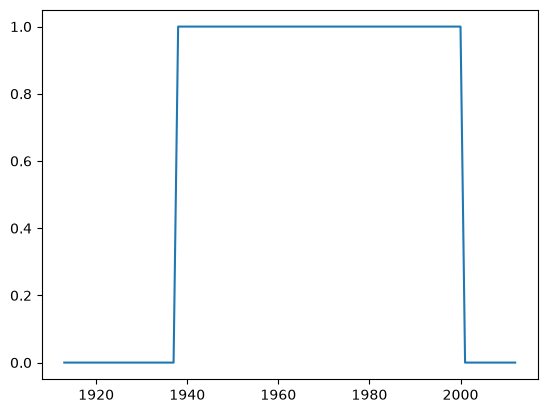

In [87]:
# plot the signal around first onset
t = onsets[0]
plt.plot(ts[t-25:t+75])

In [ ]:
# the times series has the time information in the first column, then the values
print(ts[t-25:t+75])

# here we keep only the values of the time series (signal), discarding the time
print(ts[t-25:t+75].values)

39287   -35428.409031
39288   -36443.088823
39289   -36821.727374
39290   -36361.460252
39291   -35405.967880
             ...     
39382   -35375.658915
39383   -36359.761519
39384   -36959.861155
39385   -36648.903686
39386   -35690.550290
Name: 6, Length: 100, dtype: float64
[-35428.409031 -36443.088823 -36821.727374 -36361.460252 -35405.96788
 -35404.17974  -36463.115986 -36864.016874 -36400.352287 -35417.233159
 -35382.543252 -36404.465008 -36826.912979 -36384.88488  -35398.904729
 -35348.300379 -36389.176415 -36834.691386 -36394.36202  -35427.961997
 -35390.142845 -36428.694299 -36865.000351 -36440.138392 -35460.237916
 -35401.139903 -36447.737986 -36897.991526 -36477.957544 -35508.070649
 -35420.272996 -36434.058718 -36876.712665 -36464.814718 -35498.682916
 -35408.471275 -36432.359985 -36904.875863 -36496.017754 -35534.177486
 -35411.421706 -36427.174381 -36916.856398 -36525.611463 -35562.877126
 -35405.252624 -36412.958671 -36899.243224 -36540.721243 -35570.74494
 -35413.65688

In [ ]:
# list to store time series around onsets
extracted_ts = []
# loop over onsets
for t in onsets:
    # extract 25 time points before onset and 75 time points after
    extracted_ts.append(ts[t-25:t+75].values)

120


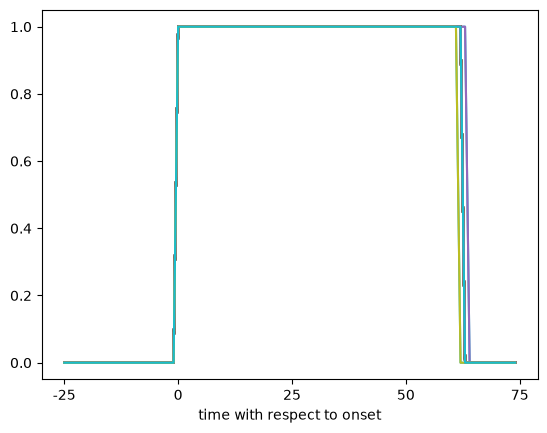

In [ ]:
# here we plot all the extracted time series around onsets


print(len(extracted_ts))
for s in extracted_ts: # loop over all elements of list, each s is a time series of 100 elements
    plt.plot(s)
# change the ticks on the x-axis to indicate 0 as onset    
plt.xticks([0,25,50,75,100],[-25,0,25,50,75])
plt.xlabel("time with respect to onset")
plt.show()

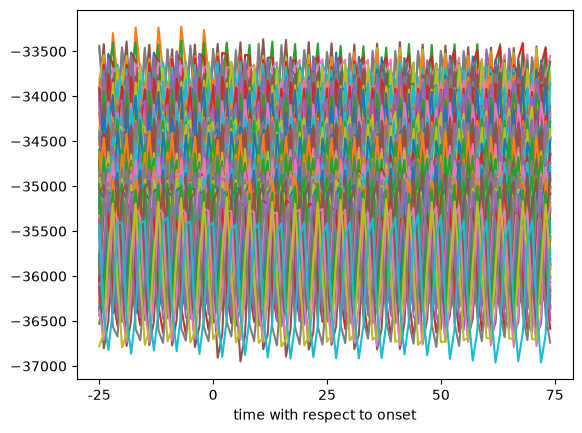

In [115]:
# here we plot the signal from another channel (column 6) around the onsets

eeg = df[6]
resp = []
for t in onsets:
    resp.append(eeg[t-25:t+75].values)
    
# plot the responses around the onsets
for s in resp:
    plt.plot(s)
plt.xticks([0,25,50,75,100],[-25,0,25,50,75])
plt.xlabel("time with respect to onset")
plt.show()

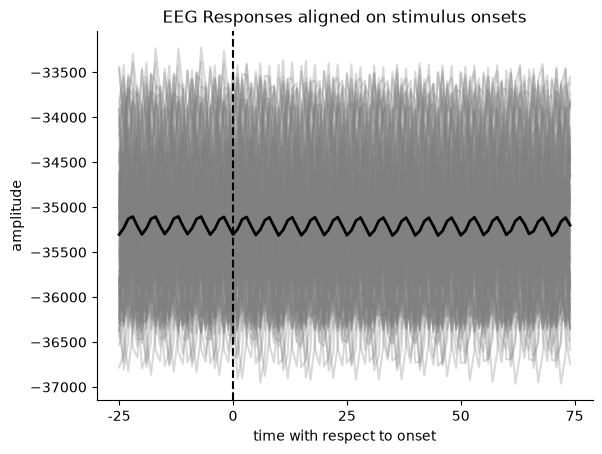

In [112]:
# plot the responses around the onsets
# here we use the subplots function to create a figure and axes object, which allows us to customize the plot more easily
# here we also plot the mean response in black with a thicker line, and add a vertical line at the onset (time 0)
# here we also hide the top and right spines of the plot for a cleaner look
# here we also set the alpha parameter to make the individual responses more transparent, so that the mean response stands out more

# here we also use the np.transpose function to transpose the list of responses, so that each response is plotted as a separate line

fig,axs=plt.subplots()

axs.plot(np.transpose(resp),'gray',alpha=0.3)  # Transpose the list of responses to plot them correctly
axs.plot(np.mean(resp,axis=0),'k',linewidth=2)  # Plot the mean response in black with thicker line
axs.set_xlabel("time with respect to onset")
axs.set_ylabel("amplitude")
axs.set_title("EEG Responses aligned on stimulus onsets")
axs.set_xticks([0,25,50,75,100])
axs.set_xticklabels([-25,0,25,50,75])
axs.axvline(25, color='k', linestyle='--')  # Add a vertical line at the onset (time 0)
axs.spines['top'].set_visible(False)  # Hide the top spine
axs.spines['right'].set_visible(False)  # Hide the right spine

We have seen how to extract portions of signals and align them to the onset times detected from the stimulus signal. Now we need to clean the signal to see the responses.

As an exercise, you can try the same code on the file "EEG_cleaned_ses.csv" (Garrido data). You will have to check the options for `read_csv`, check the column for the stimulus signal, adjust the threshold, etc.